# Hyperparameter
---


In [ ]:
# -- DATA AUGMENTATION --
# Set how many augmented variations you want per image
NUM_AUGMENTATIONS_PER_IMAGE = 6

# Download Data from Kagglehub
---


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rhythmghai/ai-vs-real-images-dataset")

print("Path to dataset files:", path)

# Import packages
---


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, Activation, GlobalAveragePooling2D
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

# Load real images
---


In [ ]:
path = kagglehub.dataset_download("rhythmghai/ai-vs-real-images-dataset")
dir = path + "/real_dataset/"

valid_extensions = (".jpg", ".jpeg", ".png")

# collect all sub-folder paths
sub_folder_paths = []

for root, dirs, files in os.walk(dir):
    for filename in files:
        if filename.lower().endswith(valid_extensions):
            sub_folder_paths.append(os.path.join(root, filename)) # append full path

images_real = [] # numpy Array (from cv2)
for path in sub_folder_paths:
    img = cv2.imread(path)

    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images_real.append(img)

print(f'loaded {len(images_real)} images')


# Load Ai generated images
---


In [ ]:
path = kagglehub.dataset_download("rhythmghai/ai-vs-real-images-dataset")
dir = path + "/Ai_generated_dataset/"
print(path)
print(dir)

valid_extensions = (".jpg", ".jpeg", ".png")

# collect all sub-folder paths
sub_folder_paths = []

for root, dirs, files in os.walk(dir):
    for filename in files:
        if filename.lower().endswith(valid_extensions):
            sub_folder_paths.append(os.path.join(root, filename)) # append full path

images_ai = []
for path in sub_folder_paths:
    img = cv2.imread(path)

    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images_ai.append(img)

print(f'loaded {len(images_ai)} images')

# Show some pictures that were loaded
---


In [ ]:
import matplotlib.pyplot as plt
import random

# Get samples from (AI, Real)
real_samples = []
ai_samples = []

random_real_indices = random.sample(range(len(images_real)), 4)
random_ai_indices = random.sample(range(len(images_ai)), 4)

# Pick 4 of each class (AI, Real)
real_samples = [images_real[i] for i in random_real_indices]
ai_samples = [images_ai[i] for i in random_ai_indices]

# Combine samples
all_samples = real_samples + ai_samples
all_labels = [0] * len(real_samples) + [1] * len(ai_samples)

# Plot
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, (img, true_label) in enumerate(zip(all_samples, all_labels)):
    axes[idx].imshow(img.astype('uint8'))

    true_class_name = "Real" if true_label == 0 else "AI"

    # Style update: Matches the "True: Class" format and styling from the second script
    title = f"True: {true_class_name}"
    axes[idx].set_title(title, color='green', fontweight='bold', fontsize=12)
    axes[idx].axis('off')

plt.suptitle('Sample Predictions: Real vs AI Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Standardize Image Sizes
----


In [ ]:
IMG_SIZE = (224,224)

processed_real = [cv2.resize(img, IMG_SIZE) for img in images_real]
processed_ai = [cv2.resize(img, IMG_SIZE) for img in images_ai]

X_real = np.array(processed_real)
X_ai = np.array(processed_ai)

y_real = np.zeros(len(X_real), dtype=np.int32)  # class 0
y_ai = np.ones(len(X_ai), dtype=np.int32)       # class 1

X_combined = np.concatenate([X_real, X_ai], axis=0)
y_combined = np.concatenate([y_real, y_ai], axis=0)

# Train, Test Split
---


In [ ]:
# Split 80/20 for training/(validation/test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_combined, y_combined,
    test_size=0.2,
    stratify=y_combined,
    random_state=42
)

# Split 50/50 for validation/test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

# Data Augmentation
---


In [ ]:
import numpy as np

# Define the transformations
augmenter = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(height_factor=0.08, width_factor=0.08),
    tf.keras.layers.RandomContrast(0.15),
])

augmented_images = []
augmented_labels = []

print(f"Original training samples: {len(X_train)}")
print("Generating extra samples...")

# Loop through training data to create fresh samples
for img, label in zip(X_train, y_train):
    # Keep the original image
    augmented_images.append(img)
    augmented_labels.append(label)

    # Generate the extra variations
    for _ in range(NUM_AUGMENTATIONS_PER_IMAGE):
        # add a batch dimension [1, H, W, C] for Keras layers, then squeeze it back to [H, W, C]
        aug_img = augmenter(np.expand_dims(img, axis=0), training=True)
        augmented_images.append(np.squeeze(aug_img, axis=0))
        augmented_labels.append(label)

# Convert back to numpy arrays
X_train_expanded = np.array(augmented_images)
y_train_expanded = np.array(augmented_labels)

print(f"Expanded training samples: {len(X_train_expanded)}")

# Build Tensorflow dataset
---


In [ ]:
BUFFER_SIZE = len(X_combined)
SPLIT = 0.8
BATCH_SIZE = 32

train_ds = (tf.data.Dataset.from_tensor_slices((X_train_expanded, y_train_expanded))
            .shuffle(BUFFER_SIZE)
            .batch(BATCH_SIZE)
            .prefetch(buffer_size=tf.data.AUTOTUNE))

test_ds = ((tf.data.Dataset.from_tensor_slices((X_test, y_test)))
           .batch(BATCH_SIZE)
           .prefetch(buffer_size=tf.data.AUTOTUNE))

val_ds = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
          .batch(BATCH_SIZE)
          .prefetch(buffer_size=tf.data.AUTOTUNE))

# Build Tensorflow CNN
---


In [ ]:
model = Sequential([
    
    ##################################################################
    # 128x128x3 -> 64x64x32                                          #
    ##################################################################
    Conv2D(32, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    Conv2D(32, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    MaxPooling2D((2, 2)),
    Dropout(0.5),

    ##################################################################
    # 64x64x32 -> 32x32x64                                           #
    ##################################################################
    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    MaxPooling2D((2, 2)),
    Dropout(0.5),

    ##################################################################
    # 32x32x64 -> 16x16x128                                          #
    ##################################################################
    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    MaxPooling2D((2, 2)),
    Dropout(0.5),

    ##################################################################
    # 16x16x128 -> 8x8x256                                           #
    ##################################################################
    Conv2D(256, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    Conv2D(256, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    MaxPooling2D((2, 2)),
    Dropout(0.5),

    ##################################################################
    # 8x8x256 -> 4x4x512                                             #
    ##################################################################
    Conv2D(512, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    Conv2D(512, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    MaxPooling2D((2, 2)),
    Dropout(0.5),

    ##################################################################
    # Classification Layers                                          #
    ##################################################################
    GlobalAveragePooling2D(),

    Dense(512),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(256),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Binary output (0 or 1)
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
    jit_compile=False
)

# Train the Model
---


In [ ]:
# Compute class weights to handle class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_combined),
    y=y_train_expanded
)

# Add class weights to the model to handle class imbalance
class_weight_dict = dict(enumerate(class_weights))

# Stops training when the validation loss stops improving
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

for i in range(1):
    print(f"Iteration {i+1}")
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=1,
        class_weight=class_weight_dict,
        callbacks=[es],
        verbose=1
    )

# Test Data with val_ds
---

In [ ]:
import numpy as np

y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

y_pred_probs = model.predict(test_ds)

# 3. Convert probabilities to binary choices (0 or 1)
y_pred = (y_pred_probs >= 0.5).astype(int).flatten()

from sklearn.metrics import classification_report

# Print precision, recall, and F1-score
print(classification_report(y_true, y_pred, target_names=['Real (0)', 'AI (1)']))

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix visually
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'AI'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Validation Confusion Matrix")
plt.show()

# Save model weights to disk
---


In [ ]:
# Save weights to disk
model.save_weights("ai_vs_real.weights.h5")

# Load model weights from disk
---


In [ ]:
# Load model from disk (with weights)
model.load_weights("ai_vs_real_best_weights.weights.h5")

# Visualize some pictures of each class with its classification
---

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step


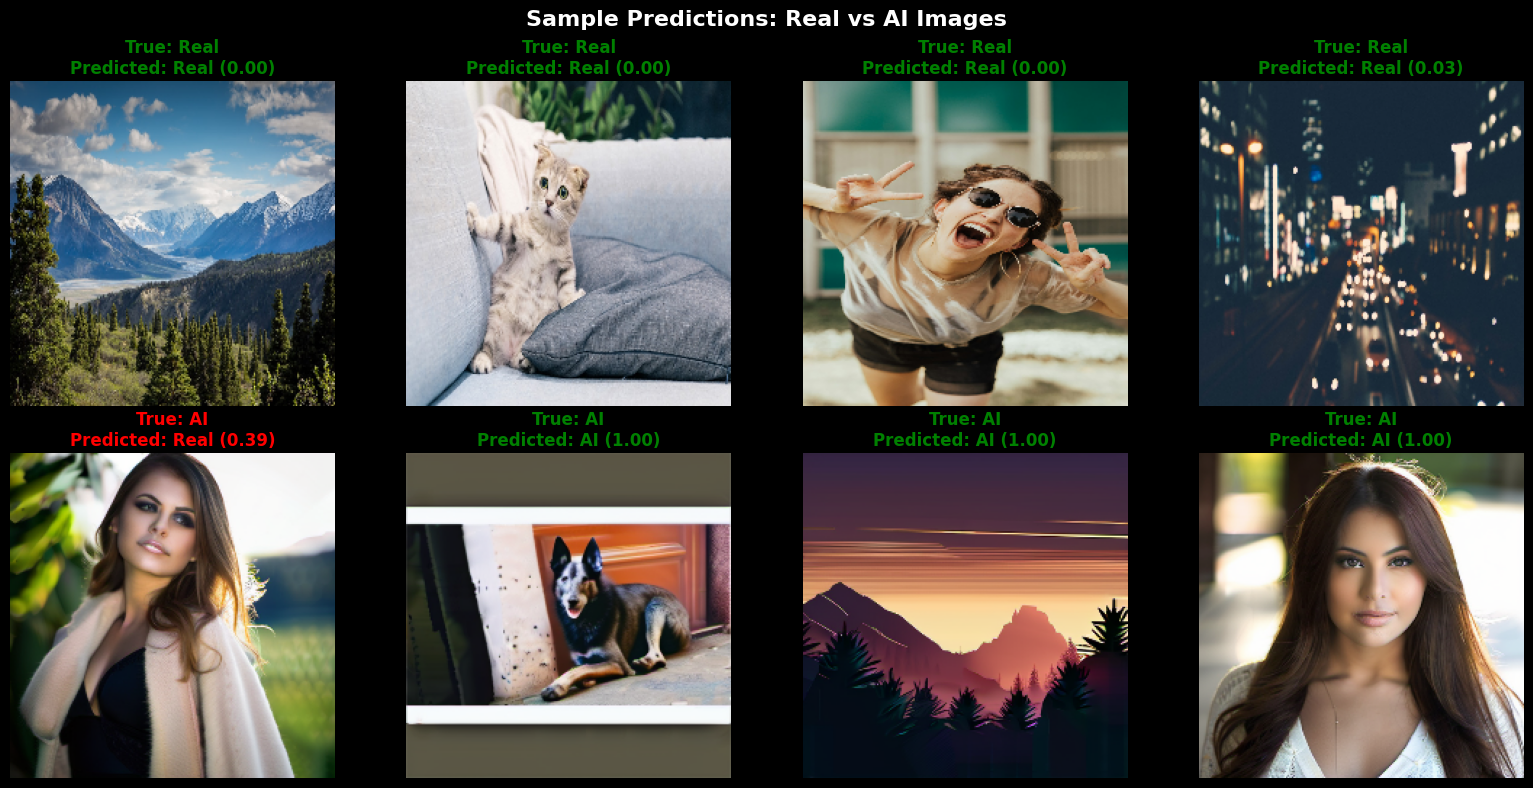

In [47]:
# Visualize sample predictions from each class
import matplotlib.pyplot as plt
import random

# Get samples from validation set
real_samples = []
ai_samples = []

# Get a pool of samples from the validation set
real_pool = []
ai_pool = []

for images, labels in test_ds:
    for img, label in zip(images.numpy(), labels.numpy()):
        if label == 0:
            real_pool.append(img)
        elif label == 1:
            ai_pool.append(img)

real_samples = random.sample(real_pool, min(4, len(real_pool)))
ai_samples = random.sample(ai_pool, min(4, len(ai_pool)))

# Combine samples
all_samples = real_samples + ai_samples
all_labels = [0]*len(real_samples) + [1]*len(ai_samples)

# Get predictions
predictions = model.predict(np.array(all_samples))
predicted_classes = (predictions >= 0.5).astype(int).flatten()

# Plot
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, (img, true_label, pred_class, pred_prob) in enumerate(zip(all_samples, all_labels, predicted_classes, predictions)):
    axes[idx].imshow(img.astype('uint8'))
    
    true_class_name = "Real" if true_label == 0 else "AI"
    pred_class_name = "Real" if pred_class == 0 else "AI"
    
    # Color: green if correct, red if wrong
    color = 'green' if true_label == pred_class else 'red'
    
    title = f"True: {true_class_name}\nPredicted: {pred_class_name} ({pred_prob[0]:.2f})"
    axes[idx].set_title(title, color=color, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Sample Predictions: Real vs AI Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()